In [1]:
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results__.html
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__notebook__.ipynb
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__output__.json
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/ResNet50_E1-E5_FINAL_CHECKPOINT.zip
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/custom.css
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/Dataset_Reports/extra_physical_images_22.csv
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/Dataset_Reports/missing_physical_images.csv
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results___files/__results___109_0.png
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results___files/__results___119_2.png
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results___files/__results___77_1.png
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results___files/__results___133_0.png
/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/__results___files

# Waste Classification — 4-Model Comparative Research

This notebook performs an **apples-to-apples comparison** of four CNN
architectures trained on the Final Waste Dataset:

| Model | Source notebook |
|---|---|
| ResNet50 | `model-training-setup-1st-model-run` |
| DenseNet121 | `model-training-setup-2nd-model-densenet121` |
| EfficientNet-B0 | `efficientnet-b0-kaggle-notebook` |
| MobileNetV3-Large | `mobilenetv3-large-complete-kaggle-research-pipel` |

**Before running this notebook on Kaggle**, attach as Input (via *Add Input → Notebook Output*):

1. `full-final-dataset-code` (provides `Final_Waste_Dataset/research_metadata/*`)
2. `model-training-setup-1st-model-run` (ResNet50 outputs)
3. `model-training-setup-2nd-model-densenet121` (DenseNet121 outputs)
4. `efficientnet-b0-kaggle-notebook` (EfficientNet-B0 outputs)
5. `mobilenetv3-large-complete-kaggle-research-pipel` (MobileNetV3-Large outputs)

**Design notes / why this version is different from the draft:**

- All accuracy / precision / recall / F1 / calibration numbers are **recomputed
  directly from the raw per-image prediction files** of every model (not read
  from each model's own `final_summary.json`). The three source notebooks each
  saved that JSON with a **different, incompatible key layout**
  (`overall_test.macro_f1` vs `performance.macro_f1` vs `overall_test.f1_macro`,
  etc.), so reading it directly — as the earlier draft did — silently returned
  `NaN` for almost every column. Recomputing from predictions makes every
  number correct, consistent, and directly comparable across models.
- **ResNet50's** training notebook does not export the standardized
  `resnet50_test_predictions.csv` / `_bangladesh_predictions.csv` /
  `_international_predictions.csv` files that the other three notebooks
  produce (only checkpoints, `history.csv`, `config.json`, and a
  `resnet50_domain_results.csv` summary table). This notebook automatically
  falls back to `resnet50_domain_results.csv` for ResNet50 so it is **never
  silently dropped** from the comparison — it clearly labels which metrics
  are full (from raw predictions) vs. reconstructed (from the domain-results
  fallback, weighted-average only, no per-class/ECE/confusion matrix).
- Every search step is defensive: missing inputs produce a clear printed
  warning and the pipeline keeps going instead of crashing on the last cell.


## STEP 01 — Environment & Imports

In [2]:
# ============================================================
# STEP 01 — ENVIRONMENT & IMPORTS
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"
np.random.seed(42)

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

print("=" * 80)
print("4-MODEL COMPARATIVE RESEARCH ENVIRONMENT")
print("=" * 80)
print("Working directory:", KAGGLE_WORKING)
print("Input directory   :", KAGGLE_INPUT)

if KAGGLE_INPUT.exists():
    print("\nKaggle inputs attached:")
    for p in sorted(KAGGLE_INPUT.iterdir()):
        print(" ->", p.name)
else:
    warnings.warn("‼ /kaggle/input does not exist — are you running this on Kaggle?")

print("\n✓ Environment ready")


4-MODEL COMPARATIVE RESEARCH ENVIRONMENT
Working directory: /kaggle/working
Input directory   : /kaggle/input

Kaggle inputs attached:
 -> notebooks

✓ Environment ready


## STEP 02 — Index every file under /kaggle/input (used by all later searches)

In [3]:
# ============================================================
# STEP 02 — INDEX ALL INPUT FILES
# ============================================================
# Every later "find the file for model X" step filters this single list
# instead of re-walking the filesystem, and matching is case-insensitive
# and substring-based so small naming differences don't break the search.

ALL_INPUT_FILES = [p for p in KAGGLE_INPUT.rglob("*") if p.is_file()] if KAGGLE_INPUT.exists() else []

print("=" * 80)
print("INPUT FILE INDEX")
print("=" * 80)
print(f"Total files indexed under /kaggle/input: {len(ALL_INPUT_FILES):,}")

def find_files(*must_contain, exts=None):
    """Return files whose lowercase name contains every token in must_contain
    (case-insensitive) and whose suffix is in exts (if given)."""
    tokens = [t.lower() for t in must_contain]
    out = []
    for p in ALL_INPUT_FILES:
        name = p.name.lower()
        if all(t in name for t in tokens):
            if exts is None or p.suffix.lower() in exts:
                out.append(p)
    return sorted(set(out))

print("✓ find_files() helper ready")


INPUT FILE INDEX
Total files indexed under /kaggle/input: 30,146
✓ find_files() helper ready


## STEP 03 — Locate the Final Waste Dataset metadata

In [4]:
# ============================================================
# STEP 03 — LOCATE FINAL WASTE DATASET METADATA
# ============================================================
# Tries several strategies in order, because Kaggle's attach path for a
# notebook's output can nest the folder differently depending on how it
# was attached (dataset vs. "notebook output").

def find_research_metadata_dir():
    # Strategy 1: a directory literally named Final_Waste_Dataset, then its
    # research_metadata subfolder.
    for root in KAGGLE_INPUT.rglob("Final_Waste_Dataset"):
        if root.is_dir():
            for meta in root.rglob("research_metadata"):
                if meta.is_dir():
                    return meta

    # Strategy 2: any directory literally named research_metadata, anywhere.
    matches = [p for p in KAGGLE_INPUT.rglob("research_metadata") if p.is_dir()]
    if matches:
        return matches[0]

    # Strategy 3: locate final_metadata.csv directly and use its parent folder.
    csvs = list(KAGGLE_INPUT.rglob("final_metadata.csv"))
    if csvs:
        return csvs[0].parent

    return None

META = find_research_metadata_dir()

print("=" * 80)
print("RESEARCH METADATA LOCATION")
print("=" * 80)

if META is None:
    warnings.warn(
        "research_metadata directory was not found under /kaggle/input. "
        "Add 'full-final-dataset-code' output as an Input. "
        "Falling back to hard-coded class names; dataset-size stats will be unavailable."
    )
else:
    print("Selected:", META)
    print("\nFiles found there:")
    for p in sorted(META.iterdir()):
        print(" ->", p.name)


RESEARCH METADATA LOCATION
Selected: /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Files found there:
 -> FINAL_CHECKPOINT.json
 -> final_metadata.csv
 -> manual_review_decisions.csv
 -> test_bangladesh_final.csv
 -> test_final.csv
 -> test_international_final.csv
 -> train_final.csv
 -> training_class_balance.csv
 -> validation_final.csv


## STEP 04 — Load dataset metadata (soft-fail: never crashes the run)

In [5]:
# ============================================================
# STEP 04 — LOAD FINAL DATASET METADATA
# ============================================================

METADATA_FILES = {
    "final": "final_metadata.csv",
    "train": "train_final.csv",
    "validation": "validation_final.csv",
    "test": "test_final.csv",
    "bangladesh_test": "test_bangladesh_final.csv",
    "international_test": "test_international_final.csv",
}

metadata_dfs = {}

print("=" * 80)
print("LOADING METADATA FILES")
print("=" * 80)

if META is not None:
    for key, filename in METADATA_FILES.items():
        path = META / filename
        if path.exists():
            metadata_dfs[key] = pd.read_csv(path)
            print(f"✓ {filename:<32} {len(metadata_dfs[key]):>7,} rows")
        else:
            print(f"✗ {filename:<32} not found")
else:
    print("Skipped — no research_metadata directory available.")

print("\n✓ Metadata loading step complete (missing files do not stop the notebook)")


LOADING METADATA FILES
✓ final_metadata.csv                10,668 rows
✓ train_final.csv                    7,245 rows
✓ validation_final.csv               1,552 rows
✓ test_final.csv                     1,871 rows
✓ test_bangladesh_final.csv            319 rows
✓ test_international_final.csv       1,289 rows

✓ Metadata loading step complete (missing files do not stop the notebook)


## STEP 05 — Class configuration

In [6]:
# ============================================================
# STEP 05 — CLASS CONFIGURATION
# ============================================================

if "final" in metadata_dfs and "class" in metadata_dfs["final"].columns:
    CLASS_NAMES = sorted(metadata_dfs["final"]["class"].dropna().unique().tolist())
else:
    # Matches the fixed label set used identically by all four training notebooks.
    CLASS_NAMES = ["Cardboard", "Glass", "Metal", "Paper", "Plastic"]

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 80)
print("CLASS CONFIGURATION")
print("=" * 80)
for idx, name in enumerate(CLASS_NAMES):
    print(f"{idx} -> {name}")
print("\nNumber of classes:", NUM_CLASSES)


CLASS CONFIGURATION
0 -> Cardboard
1 -> Glass
2 -> Metal
3 -> Paper
4 -> Plastic

Number of classes: 5


## STEP 06 — Model registry

In [7]:
# ============================================================
# STEP 06 — MODEL REGISTRY
# ============================================================
# MODEL_TOKEN is the exact filename substring each training notebook uses,
# e.g. "efficientnet_b0_test_predictions.csv". Keeping this in one place
# means every later search step stays perfectly consistent.

MODEL_TOKEN = {
    "ResNet50": "resnet50",
    "DenseNet121": "densenet121",
    "EfficientNet-B0": "efficientnet_b0",
    "MobileNetV3-Large": "mobilenetv3_large",
}

MODELS = list(MODEL_TOKEN.keys())

print("=" * 80)
print("MODEL REGISTRY")
print("=" * 80)
for model_name, token in MODEL_TOKEN.items():
    print(f"{model_name:<20} token = '{token}'")


MODEL REGISTRY
ResNet50             token = 'resnet50'
DenseNet121          token = 'densenet121'
EfficientNet-B0      token = 'efficientnet_b0'
MobileNetV3-Large    token = 'mobilenetv3_large'


## STEP 07 — Find model checkpoints (.pth)

In [8]:
# ============================================================
# FINAL RESEARCH BACKUP — ALL 4 MODELS
# ZIP + JSON + CSV + CHECKPOINTS + REPORTS + VISUALIZATIONS
# ============================================================

from pathlib import Path
import shutil
import os
import json

BACKUP_ROOT = Path("/kaggle/working/FINAL_RESEARCH_BACKUP")
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("CREATING FINAL RESEARCH BACKUP")
print("=" * 100)

# ------------------------------------------------------------
# SOURCE PATHS
# ------------------------------------------------------------

sources = {
    "ResNet50": [
        Path("/kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results"),
    ],

    "DenseNet121": [
        Path("/kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_Research"),
        Path("/kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_Research_Results"),
    ],

    "EfficientNet-B0": [
        Path("/kaggle/input/notebooks/kbmhkhan/efficientnet-b0-kaggle-notebook/efficientnet_b0_experiment"),
    ],

    # MobileNet output backup
    "MobileNetV3-Large": [
        Path("/kaggle/input/notebooks/kbmhkhan/mobilenetv3-large-complete-kaggle-research-pipel"),
    ],
}

# ------------------------------------------------------------
# COPY EXISTING MODEL RESULTS
# ------------------------------------------------------------

for model_name, paths in sources.items():

    model_dir = BACKUP_ROOT / model_name
    model_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'=' * 80}")
    print(model_name)
    print(f"{'=' * 80}")

    found = False

    for src in paths:

        if not src.exists():
            print(f"⚠ Not found: {src}")
            continue

        found = True

        destination = model_dir / src.name

        if src.is_dir():

            shutil.copytree(
                src,
                destination,
                dirs_exist_ok=True
            )

            print(f"✓ Copied directory:")
            print(f"  {src}")

        elif src.is_file():

            shutil.copy2(
                src,
                destination
            )

            print(f"✓ Copied file:")
            print(f"  {src}")

    if not found:
        print("⚠ No source found for this model.")


# ------------------------------------------------------------
# ALSO COPY MOBILE NET EXISTING BACKUP ZIP IF AVAILABLE
# ------------------------------------------------------------

possible_mobilenet_zips = [
    Path("/kaggle/input/notebooks/kbmhkhan/mobilenetv3-large-complete-kaggle-research-pipel/MOBILENETV3-LARGE_complete_backup.zip"),
    Path("/kaggle/working/MOBILENETV3-LARGE_complete_backup.zip"),
]

for zip_path in possible_mobilenet_zips:

    if zip_path.exists():

        shutil.copy2(
            zip_path,
            BACKUP_ROOT / zip_path.name
        )

        print(
            f"\n✓ MobileNetV3 backup ZIP copied:\n"
            f"  {zip_path}"
        )

        break


# ------------------------------------------------------------
# CREATE MASTER MANIFEST
# ------------------------------------------------------------

manifest = {
    "backup_name": "FINAL_RESEARCH_BACKUP",
    "purpose": "Complete research backup for 4-model waste classification study",
    "models": [
        "ResNet50",
        "DenseNet121",
        "EfficientNet-B0",
        "MobileNetV3-Large"
    ],
    "classes": [
        "Cardboard",
        "Glass",
        "Metal",
        "Paper",
        "Plastic"
    ],
    "contents": [
        "model checkpoints",
        "training histories",
        "configuration JSON files",
        "classification reports",
        "prediction CSV files",
        "performance summaries",
        "confusion matrices",
        "normalized confusion matrices",
        "training curves",
        "reliability diagrams",
        "experiment results"
    ]
}

manifest_path = BACKUP_ROOT / "MASTER_MANIFEST.json"

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4,
        ensure_ascii=False
    )

print("\n✓ MASTER_MANIFEST.json created")


# ------------------------------------------------------------
# FILE INVENTORY
# ------------------------------------------------------------

inventory = []

for file in sorted(BACKUP_ROOT.rglob("*")):

    if file.is_file():

        size_mb = file.stat().st_size / (1024 ** 2)

        inventory.append({
            "file": str(file.relative_to(BACKUP_ROOT)),
            "size_mb": round(size_mb, 3)
        })

inventory_path = BACKUP_ROOT / "FILE_INVENTORY.json"

with open(
    inventory_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        inventory,
        f,
        indent=4,
        ensure_ascii=False
    )

print("✓ FILE_INVENTORY.json created")


# ------------------------------------------------------------
# FINAL ZIP
# ------------------------------------------------------------

archive_base = Path(
    "/kaggle/working/FINAL_RESEARCH_BACKUP_ALL_MODELS"
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=BACKUP_ROOT
)

size_gb = os.path.getsize(archive_path) / (1024 ** 3)

print("\n" + "=" * 100)
print("FINAL BACKUP CREATED")
print("=" * 100)

print(f"ZIP: {archive_path}")
print(f"Size: {size_gb:.3f} GB")

print(f"\nTotal files: {len(inventory)}")

print("\n✓ ResNet50 backup")
print("✓ DenseNet121 backup")
print("✓ EfficientNet-B0 backup")
print("✓ MobileNetV3-Large backup")
print("✓ JSON metadata")
print("✓ CSV results")
print("✓ Model checkpoints")
print("✓ Reports")
print("✓ Visualizations")

print("\n✓ FINAL BACKUP READY")

CREATING FINAL RESEARCH BACKUP

ResNet50
✓ Copied directory:
  /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results

DenseNet121
✓ Copied directory:
  /kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_Research
✓ Copied directory:
  /kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_Research_Results

EfficientNet-B0
✓ Copied directory:
  /kaggle/input/notebooks/kbmhkhan/efficientnet-b0-kaggle-notebook/efficientnet_b0_experiment

MobileNetV3-Large
✓ Copied directory:
  /kaggle/input/notebooks/kbmhkhan/mobilenetv3-large-complete-kaggle-research-pipel

✓ MobileNetV3 backup ZIP copied:
  /kaggle/input/notebooks/kbmhkhan/mobilenetv3-large-complete-kaggle-research-pipel/MOBILENETV3-LARGE_complete_backup.zip

✓ MASTER_MANIFEST.json created
✓ FILE_INVENTORY.json created

FINAL BACKUP CREATED
ZIP: /kaggle/working/FINAL_RESEARCH_BACKUP_ALL_MODELS.zip
Size: 0.956 GB

Total files: 117

✓ ResNet50 backup
✓

In [9]:
# ============================================================
# FINAL BACKUP VERIFICATION
# ============================================================

from pathlib import Path
import zipfile
import os

zip_path = Path(
    "/kaggle/working/FINAL_RESEARCH_BACKUP_ALL_MODELS.zip"
)

print("=" * 100)
print("FINAL BACKUP VERIFICATION")
print("=" * 100)

print("ZIP exists:", zip_path.exists())

if zip_path.exists():

    size_gb = zip_path.stat().st_size / (1024 ** 3)

    print(f"ZIP size: {size_gb:.3f} GB")

    with zipfile.ZipFile(zip_path, "r") as z:

        files = z.namelist()

        print(f"Files inside ZIP: {len(files)}")

        print("\nModels found:")

        for model in [
            "ResNet50",
            "DenseNet121",
            "EfficientNet-B0",
            "MobileNetV3-Large"
        ]:

            found = any(model in f for f in files)

            print(
                f"{'✓' if found else '✗'} {model}"
            )

        print("\nCheckpoint files:")

        checkpoints = [
            f for f in files
            if f.endswith(".pth")
        ]

        for f in checkpoints:
            print("✓", f)

        print("\nJSON files:")

        json_files = [
            f for f in files
            if f.endswith(".json")
        ]

        for f in json_files:
            print("✓", f)

print("\n✓ VERIFICATION COMPLETE")

FINAL BACKUP VERIFICATION
ZIP exists: True
ZIP size: 0.956 GB
Files inside ZIP: 158

Models found:
✓ ResNet50
✓ DenseNet121
✓ EfficientNet-B0
✓ MobileNetV3-Large

Checkpoint files:
✓ ResNet50/waste_model_results/resnet50_experiments/E2_strong_augmentation/resnet50_best.pth
✓ ResNet50/waste_model_results/resnet50_experiments/E3_adamw_cosine/resnet50_best.pth
✓ ResNet50/waste_model_results/resnet50_experiments/E4_label_smoothing/resnet50_best.pth
✓ ResNet50/waste_model_results/resnet50_experiments/E5_high_resolution/resnet50_best.pth
✓ ResNet50/waste_model_results/checkpoints/resnet50_best.pth
✓ DenseNet121/DenseNet121_Research/checkpoints/densenet121_last.pth
✓ DenseNet121/DenseNet121_Research_Results/checkpoint/densenet121_last.pth
✓ DenseNet121/DenseNet121_Research_Results/checkpoint/densenet121_best.pth
✓ MobileNetV3-Large/mobilenetv3-large-complete-kaggle-research-pipel/mobilenetv3_large_experiment/checkpoints/mobilenetv3_large_best.pth
✓ EfficientNet-B0/efficientnet_b0_experiment/c

In [10]:
# ============================================================
# STEP 07 — FIND MODEL CHECKPOINTS
# ============================================================

model_checkpoints = {}

print("=" * 80)
print("SEARCHING MODEL CHECKPOINTS (*.pth)")
print("=" * 80)

for model_name, token in MODEL_TOKEN.items():
    found = find_files(token, exts={".pth", ".pt"})
    model_checkpoints[model_name] = found

    print(f"\n{model_name}")
    if not found:
        print("  ✗ Not found")
    else:
        for path in found:
            size_mb = path.stat().st_size / (1024 ** 2)
            print(f"  ✓ {path} ({size_mb:.2f} MB)")


SEARCHING MODEL CHECKPOINTS (*.pth)

ResNet50
  ✓ /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results/checkpoints/resnet50_best.pth (269.58 MB)
  ✓ /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results/resnet50_experiments/E2_strong_augmentation/resnet50_best.pth (90.02 MB)
  ✓ /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results/resnet50_experiments/E3_adamw_cosine/resnet50_best.pth (90.02 MB)
  ✓ /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results/resnet50_experiments/E4_label_smoothing/resnet50_best.pth (90.02 MB)
  ✓ /kaggle/input/notebooks/kbmhkhan/resnet50-final-code/waste_model_results/resnet50_experiments/E5_high_resolution/resnet50_best.pth (90.02 MB)

DenseNet121
  ✓ /kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_Research/checkpoints/densenet121_last.pth (80.53 MB)
  ✓ /kaggle/input/notebooks/kbmhkhan/model-training-setup-2nd-model-densenet121/DenseNet121_

## STEP 08 — Find standardized prediction files (test / bangladesh / international)

In [11]:
# ============================================================
# STEP 08 — FIND PREDICTION FILES
# ============================================================

PREDICTION_SUFFIX = {
    "test": "test_predictions.csv",
    "bangladesh": "bangladesh_predictions.csv",
    "international": "international_predictions.csv",
}

prediction_files = {model_name: {} for model_name in MODELS}

print("=" * 80)
print("SEARCHING STANDARDIZED PREDICTION FILES")
print("=" * 80)

for model_name, token in MODEL_TOKEN.items():
    print(f"\n{model_name}")
    for split, suffix in PREDICTION_SUFFIX.items():
        matches = find_files(f"{token}_{suffix}", exts={".csv"})
        prediction_files[model_name][split] = matches
        status = "✓" if matches else "✗"
        print(f"  {status} {split:<15}: {len(matches)} file(s)")


SEARCHING STANDARDIZED PREDICTION FILES

ResNet50
  ✓ test           : 1 file(s)
  ✓ bangladesh     : 1 file(s)
  ✓ international  : 1 file(s)

DenseNet121
  ✓ test           : 1 file(s)
  ✓ bangladesh     : 1 file(s)
  ✓ international  : 1 file(s)

EfficientNet-B0
  ✓ test           : 1 file(s)
  ✓ bangladesh     : 1 file(s)
  ✓ international  : 1 file(s)

MobileNetV3-Large
  ✓ test           : 1 file(s)
  ✓ bangladesh     : 1 file(s)
  ✓ international  : 1 file(s)


## STEP 09 — Load predictions & validate schema

In [12]:
# ============================================================
# STEP 09 — LOAD PREDICTIONS
# ============================================================

REQUIRED_PRED_COLUMNS = {"true_idx", "pred_idx", "confidence", "correct"}

predictions = {model_name: {} for model_name in MODELS}
prediction_warnings = []

print("=" * 80)
print("LOADING PREDICTION FILES")
print("=" * 80)

for model_name in MODELS:
    for split, paths in prediction_files[model_name].items():
        if not paths:
            continue
        df = pd.read_csv(paths[0])
        missing_cols = REQUIRED_PRED_COLUMNS - set(df.columns)
        if missing_cols:
            msg = f"{model_name} / {split}: missing columns {missing_cols} — file skipped"
            prediction_warnings.append(msg)
            print("  ⚠", msg)
            continue
        predictions[model_name][split] = df
        print(f"  ✓ {model_name:<20} | {split:<15} | {len(df):,} rows")

if prediction_warnings:
    print("\nWarnings:")
    for w in prediction_warnings:
        print(" -", w)


LOADING PREDICTION FILES
  ✓ ResNet50             | test            | 1,871 rows
  ✓ ResNet50             | bangladesh      | 582 rows
  ✓ ResNet50             | international   | 1,289 rows
  ✓ DenseNet121          | test            | 1,871 rows
  ✓ DenseNet121          | bangladesh      | 582 rows
  ✓ DenseNet121          | international   | 1,289 rows
  ✓ EfficientNet-B0      | test            | 1,871 rows
  ✓ EfficientNet-B0      | bangladesh      | 582 rows
  ✓ EfficientNet-B0      | international   | 1,289 rows
  ✓ MobileNetV3-Large    | test            | 1,871 rows
  ✓ MobileNetV3-Large    | bangladesh      | 582 rows
  ✓ MobileNetV3-Large    | international   | 1,289 rows


## STEP 10 — ResNet50 fallback

The ResNet50 training notebook does not export
`resnet50_test_predictions.csv` / `_bangladesh_predictions.csv` /
`_international_predictions.csv`. If those are missing, this step looks for
`resnet50_domain_results.csv`, which the notebook *does* save (columns:
`Dataset`, `Samples`, `Accuracy`, `Precision`, `Recall`, `F1`, weighted-averaged,
for the `Overall Test` / `Bangladesh Test` / `International Test` rows) and
builds a reduced-but-honest metrics record from it.

In [13]:
# ============================================================
# STEP 10 — RESNET50 FALLBACK (DOMAIN-RESULTS RECONSTRUCTION)
# ============================================================

DOMAIN_ROW_FOR_SPLIT = {
    "test": "Overall Test",
    "bangladesh": "Bangladesh Test",
    "international": "International Test",
}

reconstructed_metrics = {model_name: {} for model_name in MODELS}

print("=" * 80)
print("RESNET50 FALLBACK CHECK")
print("=" * 80)

for model_name in MODELS:
    missing_splits = [s for s in PREDICTION_SUFFIX if s not in predictions[model_name]]
    if not missing_splits:
        print(f"{model_name}: all splits have raw predictions — no fallback needed.")
        continue

    domain_files = find_files(MODEL_TOKEN[model_name], "domain_results", exts={".csv"})
    if not domain_files:
        print(f"⚠ {model_name}: missing splits {missing_splits} and no *_domain_results.csv fallback found. "
              f"These splits will show as N/A in the final comparison.")
        continue

    domain_df = pd.read_csv(domain_files[0])
    print(f"✓ {model_name}: using fallback file {domain_files[0].name} for splits {missing_splits}")

    for split in missing_splits:
        row_label = DOMAIN_ROW_FOR_SPLIT[split]
        row = domain_df[domain_df["Dataset"] == row_label]
        if row.empty:
            print(f"  ⚠ row '{row_label}' not found inside {domain_files[0].name}")
            continue
        row = row.iloc[0]
        reconstructed_metrics[model_name][split] = {
            "source": "reconstructed (weighted avg only, no per-class/ECE/confusion-matrix)",
            "n_samples": int(row.get("Samples", np.nan)) if not pd.isna(row.get("Samples", np.nan)) else None,
            "accuracy": float(row.get("Accuracy", np.nan)),
            "weighted_precision": float(row.get("Precision", np.nan)),
            "weighted_recall": float(row.get("Recall", np.nan)),
            "weighted_f1": float(row.get("F1", np.nan)),
            "macro_precision": np.nan,
            "macro_recall": np.nan,
            "macro_f1": np.nan,
            "ece": np.nan,
            "n_errors": (
                int(round((1 - float(row.get("Accuracy", np.nan))) * float(row.get("Samples", np.nan))))
                if not pd.isna(row.get("Accuracy", np.nan)) and not pd.isna(row.get("Samples", np.nan))
                else None
            ),
            "confusion_matrix": None,
            "per_class_f1": None,
        }
        print(f"  -> {split}: accuracy={reconstructed_metrics[model_name][split]['accuracy']:.4f} (reconstructed)")


RESNET50 FALLBACK CHECK
ResNet50: all splits have raw predictions — no fallback needed.
DenseNet121: all splits have raw predictions — no fallback needed.
EfficientNet-B0: all splits have raw predictions — no fallback needed.
MobileNetV3-Large: all splits have raw predictions — no fallback needed.


## STEP 11 — Unified metric functions (computed identically for every model)

In [14]:
# ============================================================
# STEP 11 — UNIFIED METRIC FUNCTIONS
# ============================================================

def compute_ece(confidence, correct, n_bins=10):
    """Expected Calibration Error with equal-width confidence bins."""
    confidence = np.asarray(confidence, dtype=float)
    correct = np.asarray(correct, dtype=bool)
    n = len(confidence)
    if n == 0:
        return np.nan
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (confidence >= lo) & (confidence <= hi if i == n_bins - 1 else confidence < hi)
        if mask.sum() == 0:
            continue
        bin_acc = correct[mask].mean()
        bin_conf = confidence[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
    return float(ece)


def compute_metrics_from_predictions(df, num_classes=NUM_CLASSES):
    """Compute a full, consistent metrics record from a raw prediction dataframe."""
    y_true = df["true_idx"].to_numpy()
    y_pred = df["pred_idx"].to_numpy()

    accuracy = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    _, _, per_class_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_classes)), zero_division=0
    )

    ece = compute_ece(df["confidence"], df["correct"])
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    return {
        "source": "raw predictions",
        "n_samples": int(len(df)),
        "accuracy": float(accuracy),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
        "ece": float(ece),
        "n_errors": int((~df["correct"].astype(bool)).sum()),
        "confusion_matrix": cm,
        "per_class_f1": dict(zip(CLASS_NAMES, per_class_f1.tolist())),
    }

print("✓ compute_ece() and compute_metrics_from_predictions() ready")


✓ compute_ece() and compute_metrics_from_predictions() ready


## STEP 12 — Compute metrics for every model / every split

In [15]:
# ============================================================
# STEP 12 — COMPUTE METRICS FOR EVERY MODEL / SPLIT
# ============================================================

all_metrics = {model_name: {} for model_name in MODELS}

print("=" * 80)
print("COMPUTING METRICS")
print("=" * 80)

for model_name in MODELS:
    print(f"\n{model_name}")
    for split in PREDICTION_SUFFIX:
        if split in predictions[model_name]:
            all_metrics[model_name][split] = compute_metrics_from_predictions(predictions[model_name][split])
            m = all_metrics[model_name][split]
            print(f"  {split:<15}: accuracy={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}  n={m['n_samples']:,}")
        elif split in reconstructed_metrics[model_name]:
            all_metrics[model_name][split] = reconstructed_metrics[model_name][split]
            m = all_metrics[model_name][split]
            print(f"  {split:<15}: accuracy={m['accuracy']:.4f}  (reconstructed, macro metrics N/A)")
        else:
            all_metrics[model_name][split] = None
            print(f"  {split:<15}: ✗ unavailable")


COMPUTING METRICS

ResNet50
  test           : accuracy=0.9947  macro_f1=0.9946  n=1,871
  bangladesh     : accuracy=0.9845  macro_f1=0.9764  n=582
  international  : accuracy=0.9992  macro_f1=0.9993  n=1,289

DenseNet121
  test           : accuracy=0.9947  macro_f1=0.9946  n=1,871
  bangladesh     : accuracy=0.9880  macro_f1=0.9847  n=582
  international  : accuracy=0.9977  macro_f1=0.9978  n=1,289

EfficientNet-B0
  test           : accuracy=0.9936  macro_f1=0.9933  n=1,871
  bangladesh     : accuracy=0.9828  macro_f1=0.9698  n=582
  international  : accuracy=0.9984  macro_f1=0.9985  n=1,289

MobileNetV3-Large
  test           : accuracy=0.9904  macro_f1=0.9904  n=1,871
  bangladesh     : accuracy=0.9742  macro_f1=0.9663  n=582
  international  : accuracy=0.9977  macro_f1=0.9977  n=1,289


## STEP 13 — Supplementary info from each model's own summary file

Each source notebook's `*_final_summary.json` uses a **different nested
key layout** (confirmed by inspecting all three), so a single flat
`.get("key")` lookup — as in the earlier draft — silently returns nothing.
`deep_get` below tries every known layout in turn. This step is used only
for *supplementary* info (parameter count, best epoch); the actual
accuracy/F1/etc. comparison always comes from STEP 12, not from this file.

In [16]:
# ============================================================
# STEP 13 — SUPPLEMENTARY INFO FROM SUMMARY / CONFIG FILES
# ============================================================

def deep_get(d, candidate_paths, default=None):
    """Try several nested key paths (each a tuple of keys) against dict d,
    returning the first one that resolves."""
    for path in candidate_paths:
        cur = d
        ok = True
        for key in path:
            if isinstance(cur, dict) and key in cur:
                cur = cur[key]
            else:
                ok = False
                break
        if ok:
            return cur
    return default

TOTAL_PARAM_PATHS = [
    ("model_parameters", "total_parameters"),
    ("model_parameters", "total"),
    ("model_parameters",),          # DenseNet121 stores this as a flat int
]
BEST_EPOCH_PATHS = [
    ("training", "best_epoch"),
    ("experiment", "best_epoch"),
    ("best_epoch",),
]

model_supplementary = {}

print("=" * 80)
print("LOADING SUMMARY / CONFIG FILES (supplementary info only)")
print("=" * 80)

for model_name, token in MODEL_TOKEN.items():
    info = {"total_parameters": None, "best_epoch": None, "summary_source": None}

    summary_files = find_files(token, "final_summary", exts={".json"})
    if summary_files:
        with open(summary_files[0], "r", encoding="utf-8") as f:
            data = json.load(f)
        info["total_parameters"] = deep_get(data, TOTAL_PARAM_PATHS)
        info["best_epoch"] = deep_get(data, BEST_EPOCH_PATHS)
        info["summary_source"] = summary_files[0].name
    else:
        # ResNet50 fallback: config.json only has per-experiment info, no
        # param count — leave as None rather than guessing.
        config_files = find_files(token, "config", exts={".json"})
        if config_files:
            with open(config_files[0], "r", encoding="utf-8") as f:
                data = json.load(f)
            info["best_epoch"] = deep_get(data, BEST_EPOCH_PATHS)
            info["summary_source"] = config_files[0].name

    model_supplementary[model_name] = info
    print(f"{model_name:<20} source={info['summary_source']!s:<40} "
          f"params={info['total_parameters']!s:<12} best_epoch={info['best_epoch']}")


LOADING SUMMARY / CONFIG FILES (supplementary info only)
ResNet50             source=resnet50_final_summary.json              params=23518277     best_epoch=None
DenseNet121          source=densenet121_final_summary.json           params=6958981      best_epoch=20
EfficientNet-B0      source=efficientnet_b0_final_summary.json       params=4013953      best_epoch=14
MobileNetV3-Large    source=mobilenetv3_large_final_summary.json     params=4208437      best_epoch=13


## STEP 14 — Build the four-model comparison table

In [17]:
# ============================================================
# STEP 14 — FOUR MODEL COMPARISON TABLE
# ============================================================

def pct_or_nan(v):
    return float(v) if v is not None and not (isinstance(v, float) and np.isnan(v)) else np.nan

rows = []
for model_name in MODELS:
    test_m = all_metrics[model_name].get("test")
    bd_m = all_metrics[model_name].get("bangladesh")
    intl_m = all_metrics[model_name].get("international")
    supp = model_supplementary[model_name]

    rows.append({
        "Model": model_name,
        "Test Samples": test_m["n_samples"] if test_m else np.nan,
        "Accuracy": pct_or_nan(test_m["accuracy"]) if test_m else np.nan,
        "Macro Precision": pct_or_nan(test_m.get("macro_precision")) if test_m else np.nan,
        "Macro Recall": pct_or_nan(test_m.get("macro_recall")) if test_m else np.nan,
        "Macro F1": pct_or_nan(test_m.get("macro_f1")) if test_m else np.nan,
        "Weighted F1": pct_or_nan(test_m.get("weighted_f1")) if test_m else np.nan,
        "ECE": pct_or_nan(test_m.get("ece")) if test_m else np.nan,
        "Errors": test_m["n_errors"] if test_m else np.nan,
        "Bangladesh Accuracy": pct_or_nan(bd_m["accuracy"]) if bd_m else np.nan,
        "International Accuracy": pct_or_nan(intl_m["accuracy"]) if intl_m else np.nan,
        "Total Parameters": supp["total_parameters"],
        "Data Source": test_m["source"] if test_m else "unavailable",
    })

comparison_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False, na_position="last").reset_index(drop=True)

print("=" * 80)
print("FOUR MODEL COMPARISON")
print("=" * 80)
display(comparison_df)

incomplete = comparison_df[comparison_df["Data Source"] != "raw predictions"]
if not incomplete.empty:
    print("\n⚠ The following model(s) use reconstructed or unavailable data for one or more")
    print("  splits (see STEP 10) — their Macro Precision/Recall/F1 and ECE are N/A:")
    for name in incomplete["Model"]:
        print("   -", name)


FOUR MODEL COMPARISON


,Model,Test Samples,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ECE,Errors,Bangladesh Accuracy,International Accuracy,Total Parameters,Data Source
0,ResNet50,1871,0.994655,0.995115,0.994061,0.994575,0.994650,0.002433,10,0.984536,0.999224,23518277,raw predictions
1,DenseNet121,1871,0.994655,0.994333,0.994845,0.994574,0.994657,0.003094,10,0.987973,0.997673,6958981,raw predictions
2,EfficientNet-B0,1871,0.993586,0.993002,0.993669,0.993327,0.993587,0.003647,12,0.982818,0.998448,4013953,raw predictions
3,MobileNetV3-Large,1871,0.990379,0.990106,0.990646,0.990355,0.990368,0.004608,18,0.974227,0.997673,4208437,raw predictions


## STEP 15 — Save the comparison table

In [18]:
# ============================================================
# STEP 15 — SAVE MODEL COMPARISON
# ============================================================

COMPARISON_DIR = KAGGLE_WORKING / "four_model_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = COMPARISON_DIR / "four_model_performance_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)


Saved: /kaggle/working/four_model_comparison/four_model_performance_comparison.csv


## STEP 16 — Accuracy comparison

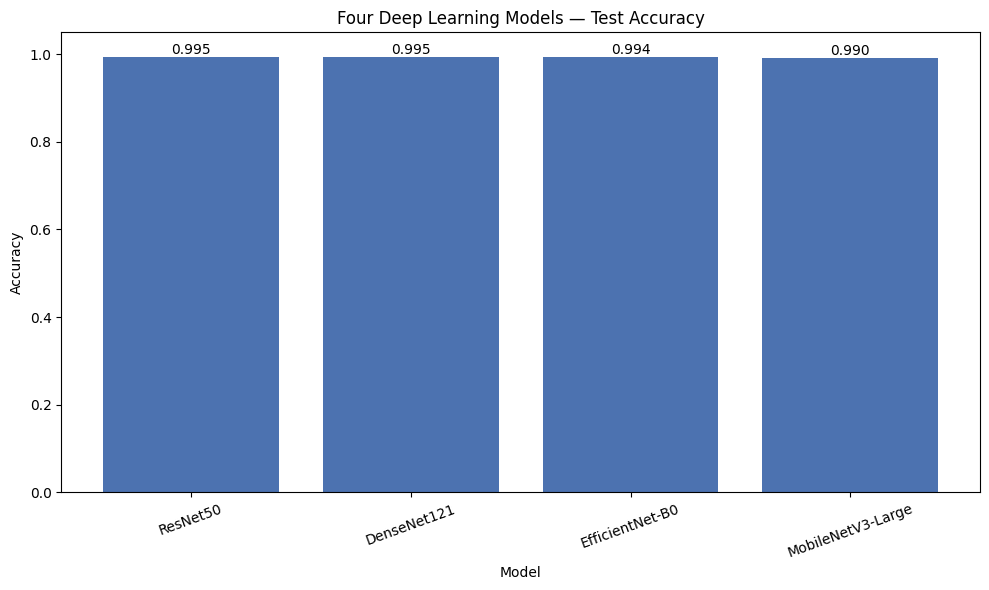

Saved: /kaggle/working/four_model_comparison/four_model_accuracy_comparison.png


In [19]:
# ============================================================
# STEP 16 — ACCURACY COMPARISON
# ============================================================

plot_df = comparison_df.dropna(subset=["Accuracy"])

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["Model"], plot_df["Accuracy"], color="#4C72B0")
plt.bar_label(bars, fmt="%.3f")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Four Deep Learning Models — Test Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.tight_layout()

accuracy_path = COMPARISON_DIR / "four_model_accuracy_comparison.png"
plt.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", accuracy_path)


## STEP 17 — Macro F1 comparison

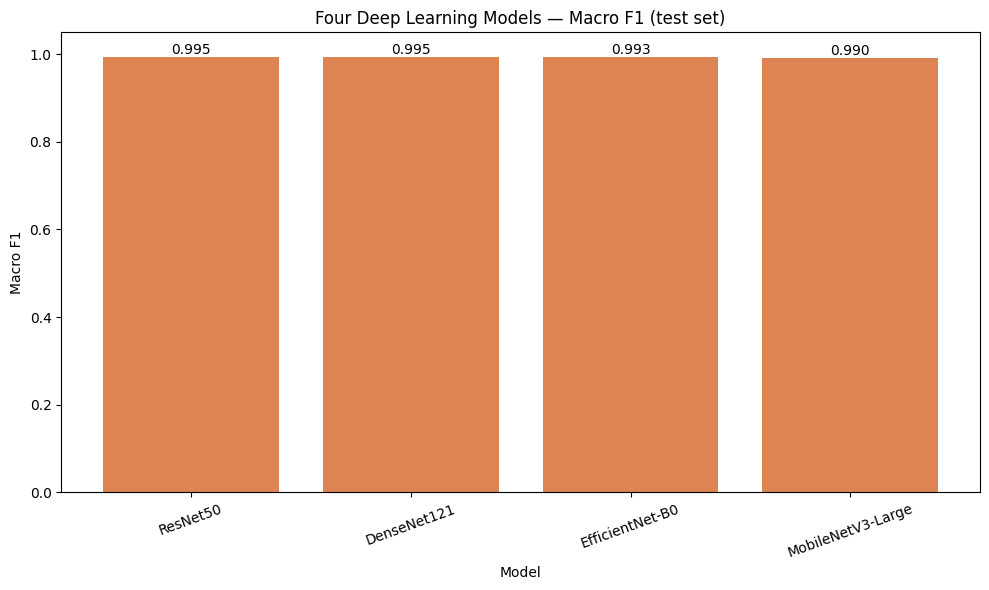

Saved: /kaggle/working/four_model_comparison/four_model_macro_f1_comparison.png


In [20]:
# ============================================================
# STEP 17 — MACRO F1 COMPARISON
# ============================================================

plot_df = comparison_df.dropna(subset=["Macro F1"])

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["Model"], plot_df["Macro F1"], color="#DD8452")
plt.bar_label(bars, fmt="%.3f")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.title("Four Deep Learning Models — Macro F1 (test set)")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.tight_layout()

f1_path = COMPARISON_DIR / "four_model_macro_f1_comparison.png"
plt.savefig(f1_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f1_path)

if len(plot_df) < len(comparison_df):
    missing = set(comparison_df["Model"]) - set(plot_df["Model"])
    print(f"\nNote: {sorted(missing)} excluded — Macro F1 unavailable (reconstructed data only).")


## STEP 18 — Bangladesh vs. International accuracy

,Model,Bangladesh Accuracy,International Accuracy
0,ResNet50,0.984536,0.999224
1,DenseNet121,0.987973,0.997673
2,EfficientNet-B0,0.982818,0.998448
3,MobileNetV3-Large,0.974227,0.997673


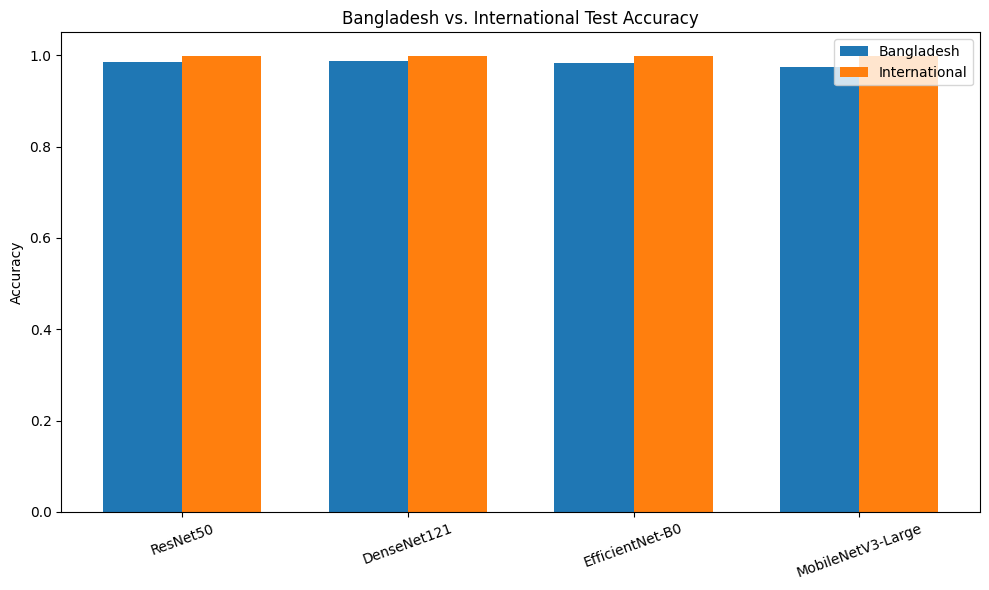

Saved: /kaggle/working/four_model_comparison/bangladesh_vs_international_accuracy.png


In [21]:
# ============================================================
# STEP 18 — DOMAIN ACCURACY COMPARISON
# ============================================================

domain_df = comparison_df[["Model", "Bangladesh Accuracy", "International Accuracy"]].copy()
display(domain_df)

plot_df = domain_df.dropna(subset=["Bangladesh Accuracy", "International Accuracy"], how="all")
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, plot_df["Bangladesh Accuracy"], width, label="Bangladesh")
plt.bar(x + width / 2, plot_df["International Accuracy"], width, label="International")
plt.xticks(x, plot_df["Model"], rotation=20)
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Bangladesh vs. International Test Accuracy")
plt.legend()
plt.tight_layout()

domain_path = COMPARISON_DIR / "bangladesh_vs_international_accuracy.png"
plt.savefig(domain_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", domain_path)


## STEP 19 — Per-class F1 heatmap (models with raw predictions only)

,Cardboard,Glass,Metal,Paper,Plastic
ResNet50,0.994,0.999,0.991,0.996,0.993
DenseNet121,0.994,0.996,0.993,0.996,0.993
EfficientNet-B0,0.989,0.997,0.993,0.994,0.993
MobileNetV3-Large,0.993,0.993,0.985,0.993,0.988


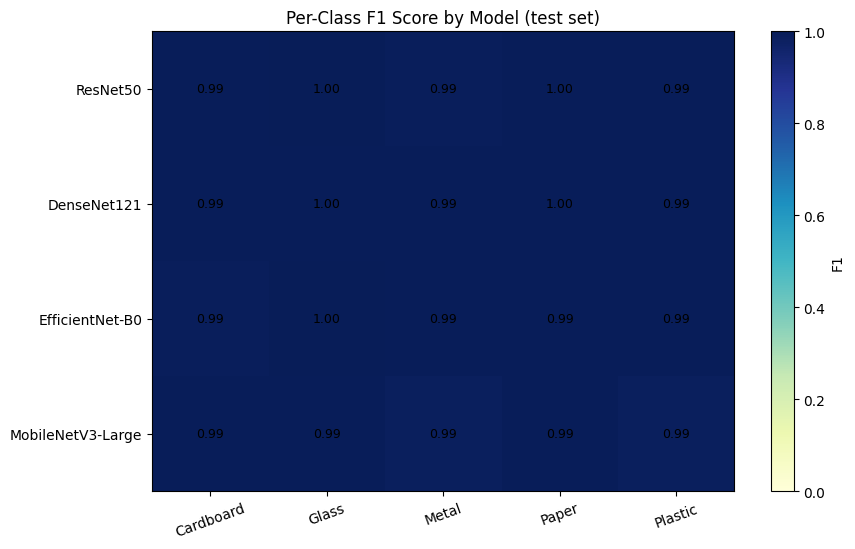

Saved: /kaggle/working/four_model_comparison/per_class_f1_heatmap.png


In [22]:
# ============================================================
# STEP 19 — PER-CLASS F1 HEATMAP
# ============================================================

per_class_rows = {}
for model_name in MODELS:
    test_m = all_metrics[model_name].get("test")
    if test_m and test_m.get("per_class_f1"):
        per_class_rows[model_name] = test_m["per_class_f1"]

if not per_class_rows:
    print("No model has per-class F1 available (all rely on reconstructed data) — skipping heatmap.")
else:
    per_class_df = pd.DataFrame(per_class_rows).T[CLASS_NAMES]
    display(per_class_df.style.format("{:.3f}").background_gradient(cmap="YlGnBu", axis=None))

    fig, ax = plt.subplots(figsize=(9, 0.9 * len(per_class_df) + 2))
    im = ax.imshow(per_class_df.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_yticks(range(len(per_class_df)))
    ax.set_yticklabels(per_class_df.index)
    for i in range(per_class_df.shape[0]):
        for j in range(per_class_df.shape[1]):
            ax.text(j, i, f"{per_class_df.values[i, j]:.2f}", ha="center", va="center",
                    color="black", fontsize=9)
    plt.colorbar(im, ax=ax, label="F1")
    plt.title("Per-Class F1 Score by Model (test set)")
    plt.tight_layout()

    per_class_path = COMPARISON_DIR / "per_class_f1_heatmap.png"
    plt.savefig(per_class_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", per_class_path)

    missing_models = set(MODELS) - set(per_class_rows)
    if missing_models:
        print(f"\nNote: {sorted(missing_models)} excluded — per-class F1 needs raw predictions.")


## STEP 20 — Confusion matrices (models with raw predictions only)

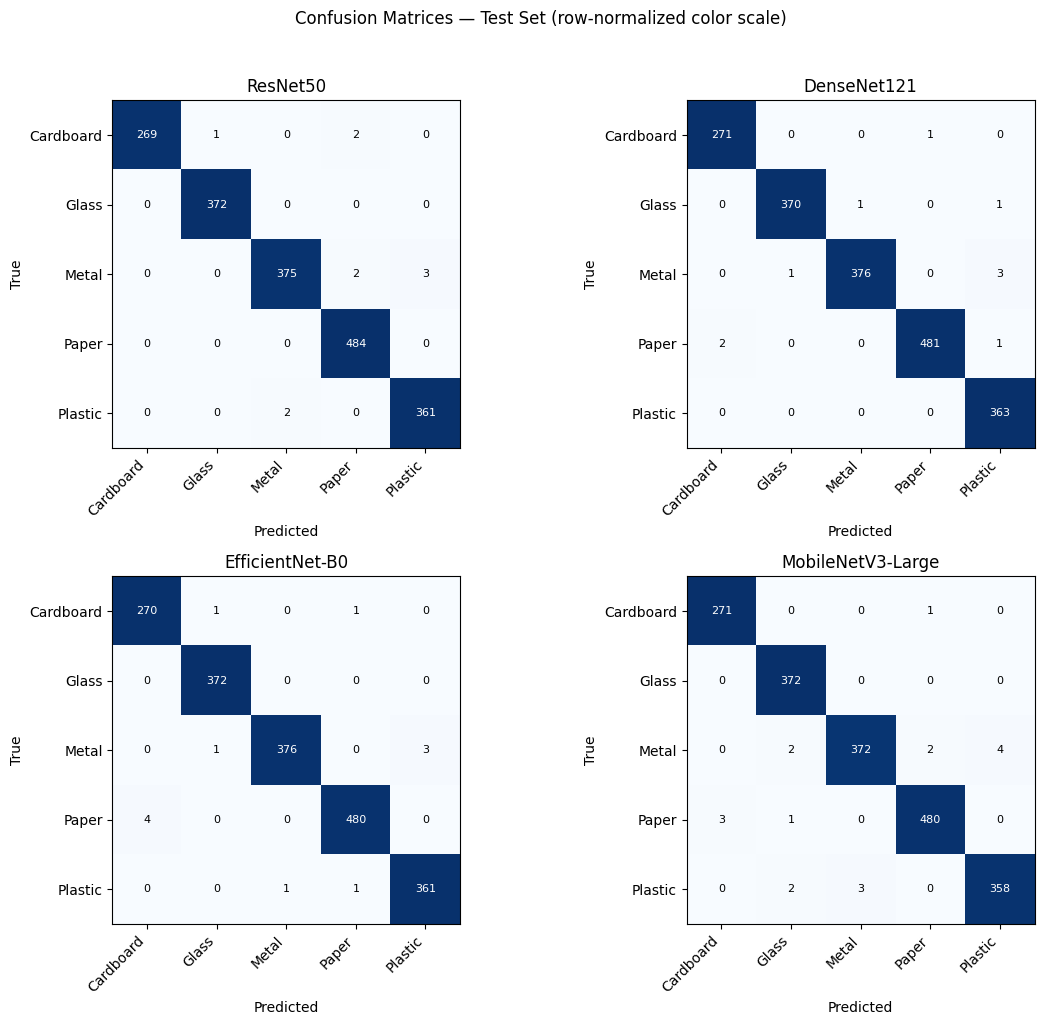

Saved: /kaggle/working/four_model_comparison/confusion_matrices_grid.png


In [23]:
# ============================================================
# STEP 20 — CONFUSION MATRIX GRID
# ============================================================

models_with_cm = [m for m in MODELS if all_metrics[m].get("test") and all_metrics[m]["test"].get("confusion_matrix") is not None]

if not models_with_cm:
    print("No confusion matrices available — skipping.")
else:
    n = len(models_with_cm)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, model_name in zip(axes, models_with_cm):
        cm = all_metrics[model_name]["test"]["confusion_matrix"]
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(model_name)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)

    for ax in axes[len(models_with_cm):]:
        ax.axis("off")

    plt.suptitle("Confusion Matrices — Test Set (row-normalized color scale)", y=1.02)
    plt.tight_layout()

    cm_path = COMPARISON_DIR / "confusion_matrices_grid.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)

    missing_models = set(MODELS) - set(models_with_cm)
    if missing_models:
        print(f"\nNote: {sorted(missing_models)} excluded — confusion matrix needs raw predictions.")


## STEP 21 — Calibration (ECE) comparison

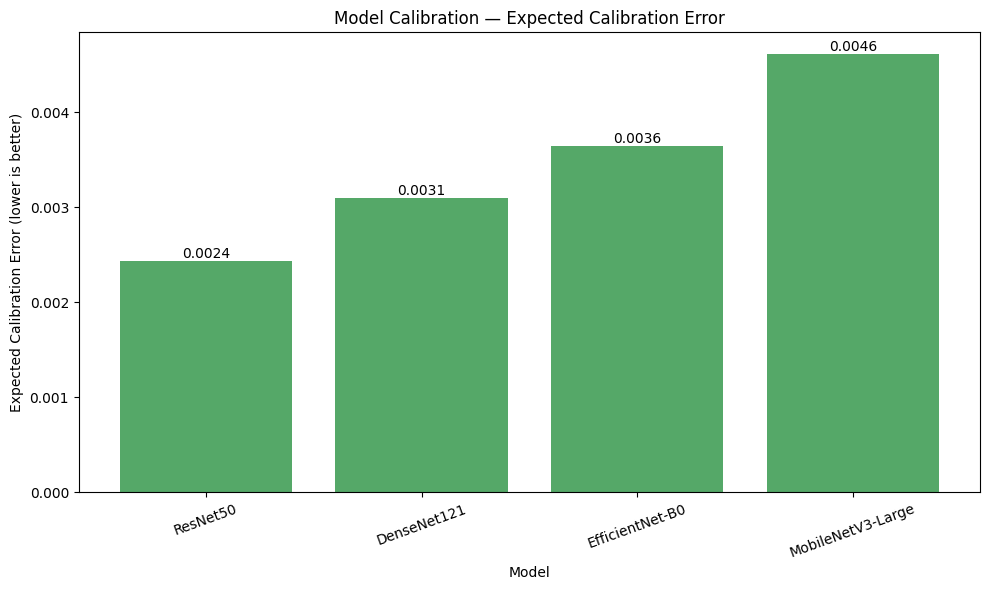

Saved: /kaggle/working/four_model_comparison/calibration_ece_comparison.png


In [24]:
# ============================================================
# STEP 21 — CALIBRATION (ECE) COMPARISON
# ============================================================

plot_df = comparison_df.dropna(subset=["ECE"])

if plot_df.empty:
    print("No model has ECE available — skipping.")
else:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(plot_df["Model"], plot_df["ECE"], color="#55A868")
    plt.bar_label(bars, fmt="%.4f")
    plt.ylabel("Expected Calibration Error (lower is better)")
    plt.xlabel("Model")
    plt.title("Model Calibration — Expected Calibration Error")
    plt.xticks(rotation=20)
    plt.tight_layout()

    ece_path = COMPARISON_DIR / "calibration_ece_comparison.png"
    plt.savefig(ece_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", ece_path)


## STEP 22 — Overall ranking radar chart

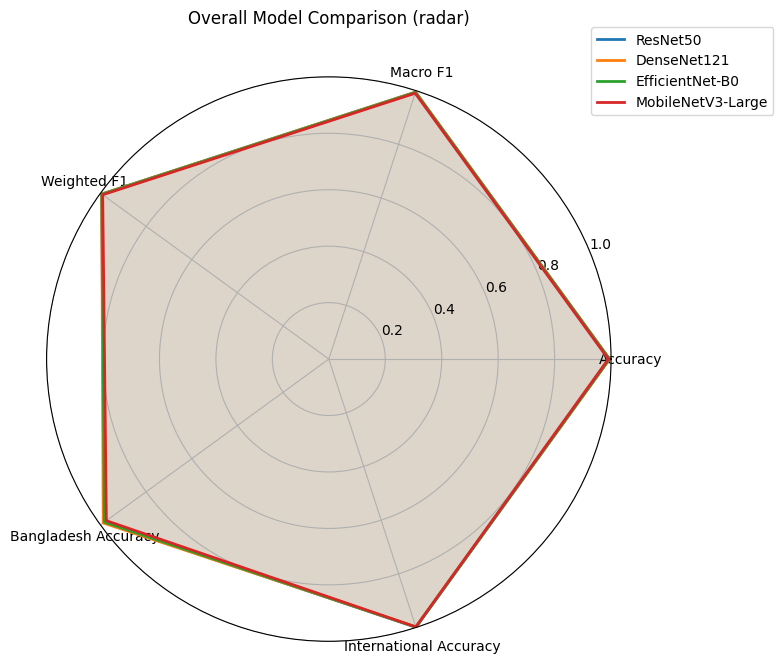

Saved: /kaggle/working/four_model_comparison/overall_radar_comparison.png

Note: rows with reconstructed-only data show 0 for unavailable metrics on the radar (not a true score).


In [25]:
# ============================================================
# STEP 22 — OVERALL RANKING RADAR CHART
# ============================================================

radar_metrics = ["Accuracy", "Macro F1", "Weighted F1", "Bangladesh Accuracy", "International Accuracy"]
radar_df = comparison_df.set_index("Model")[radar_metrics]

if radar_df.dropna(how="all").empty:
    print("Not enough data for a radar chart — skipping.")
else:
    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for model_name in radar_df.index:
        values = radar_df.loc[model_name].fillna(0).tolist()
        values += values[:1]
        ax.plot(angles, values, label=model_name, linewidth=2)
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics)
    ax.set_ylim(0, 1)
    ax.set_title("Overall Model Comparison (radar)", y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()

    radar_path = COMPARISON_DIR / "overall_radar_comparison.png"
    plt.savefig(radar_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", radar_path)
    print("\nNote: rows with reconstructed-only data show 0 for unavailable metrics on the radar (not a true score).")


## STEP 23 — Best model selection

In [26]:
# ============================================================
# STEP 23 — BEST MODEL SELECTION
# ============================================================

valid_comparison = comparison_df.dropna(subset=["Accuracy"]).copy()

print("=" * 80)
print("MODEL RANKING (by test accuracy)")
print("=" * 80)

if valid_comparison.empty:
    print("⚠ No model has a usable accuracy value — cannot determine a best model.")
    best_model_row = None
else:
    ranked = valid_comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)
    display(ranked[["Model", "Accuracy", "Macro F1", "Weighted F1", "Bangladesh Accuracy", "International Accuracy"]])

    best_model_row = ranked.iloc[0]
    print("\nBEST MODEL")
    print("-" * 40)
    print("Model   :", best_model_row["Model"])
    print(f"Accuracy: {best_model_row['Accuracy']:.4%}")
    if not pd.isna(best_model_row["Macro F1"]):
        print(f"Macro F1: {best_model_row['Macro F1']:.4%}")
    else:
        print("Macro F1: N/A (reconstructed data only for this model)")


MODEL RANKING (by test accuracy)


,Model,Accuracy,Macro F1,Weighted F1,Bangladesh Accuracy,International Accuracy
0,ResNet50,0.994655,0.994575,0.994650,0.984536,0.999224
1,DenseNet121,0.994655,0.994574,0.994657,0.987973,0.997673
2,EfficientNet-B0,0.993586,0.993327,0.993587,0.982818,0.998448
3,MobileNetV3-Large,0.990379,0.990355,0.990368,0.974227,0.997673



BEST MODEL
----------------------------------------
Model   : ResNet50
Accuracy: 99.4655%
Macro F1: 99.4575%


## STEP 24 — Written research summary

In [27]:
# ============================================================
# STEP 24 — WRITTEN RESEARCH SUMMARY
# ============================================================

lines = []
lines.append("# 4-Model Comparative Research — Summary Report\n")
lines.append(f"Classes: {', '.join(CLASS_NAMES)}\n")
lines.append("## Results\n")
lines.append(comparison_df.to_markdown(index=False))
lines.append("\n\n## Data completeness\n")

for model_name in MODELS:
    test_m = all_metrics[model_name].get("test")
    if test_m is None:
        lines.append(f"- **{model_name}**: no test-set data found at all.\n")
    elif test_m["source"] == "raw predictions":
        lines.append(f"- **{model_name}**: full metrics computed from raw per-image predictions.\n")
    else:
        lines.append(f"- **{model_name}**: reconstructed from `*_domain_results.csv` "
                      f"(weighted precision/recall/F1 and accuracy only; macro metrics, ECE, "
                      f"confusion matrix, and per-class F1 are not available because the source "
                      f"notebook does not export raw per-image predictions).\n")

if best_model_row is not None:
    lines.append(f"\n## Best model\n\n**{best_model_row['Model']}** achieved the highest test "
                  f"accuracy ({best_model_row['Accuracy']:.4%}) among models with full comparable data.\n")

lines.append("\n## Recommendation\n")
lines.append("To get a fully apples-to-apples comparison (including ResNet50's macro metrics, "
              "ECE, confusion matrix, and per-class F1), re-run the ResNet50 training notebook with "
              "a final cell that exports `resnet50_test_predictions.csv`, "
              "`resnet50_bangladesh_predictions.csv`, and `resnet50_international_predictions.csv` "
              "using the same `true_idx, pred_idx, true_class, pred_class, confidence, correct, "
              "prob_<class>` schema used by the other three notebooks.\n")

report_md = "\n".join(lines)
report_path = COMPARISON_DIR / "four_model_research_summary.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_md)

display(Markdown(report_md))
print("\nSaved:", report_path)


# 4-Model Comparative Research — Summary Report

Classes: Cardboard, Glass, Metal, Paper, Plastic

## Results

| Model             |   Test Samples |   Accuracy |   Macro Precision |   Macro Recall |   Macro F1 |   Weighted F1 |        ECE |   Errors |   Bangladesh Accuracy |   International Accuracy |   Total Parameters | Data Source     |
|:------------------|---------------:|-----------:|------------------:|---------------:|-----------:|--------------:|-----------:|---------:|----------------------:|-------------------------:|-------------------:|:----------------|
| ResNet50          |           1871 |   0.994655 |          0.995115 |       0.994061 |   0.994575 |      0.99465  | 0.00243259 |       10 |              0.984536 |                 0.999224 |           23518277 | raw predictions |
| DenseNet121       |           1871 |   0.994655 |          0.994333 |       0.994845 |   0.994574 |      0.994657 | 0.00309421 |       10 |              0.987973 |                 0.997673 |            6958981 | raw predictions |
| EfficientNet-B0   |           1871 |   0.993586 |          0.993002 |       0.993669 |   0.993327 |      0.993587 | 0.00364741 |       12 |              0.982818 |                 0.998448 |            4013953 | raw predictions |
| MobileNetV3-Large |           1871 |   0.990379 |          0.990106 |       0.990646 |   0.990355 |      0.990368 | 0.00460783 |       18 |              0.974227 |                 0.997673 |            4208437 | raw predictions |


## Data completeness

- **ResNet50**: full metrics computed from raw per-image predictions.

- **DenseNet121**: full metrics computed from raw per-image predictions.

- **EfficientNet-B0**: full metrics computed from raw per-image predictions.

- **MobileNetV3-Large**: full metrics computed from raw per-image predictions.


## Best model

**ResNet50** achieved the highest test accuracy (99.4655%) among models with full comparable data.


## Recommendation

To get a fully apples-to-apples comparison (including ResNet50's macro metrics, ECE, confusion matrix, and per-class F1), re-run the ResNet50 training notebook with a final cell that exports `resnet50_test_predictions.csv`, `resnet50_bangladesh_predictions.csv`, and `resnet50_international_predictions.csv` using the same `true_idx, pred_idx, true_class, pred_class, confidence, correct, prob_<class>` schema used by the other three notebooks.



Saved: /kaggle/working/four_model_comparison/four_model_research_summary.md


## STEP 25 — Output manifest / final verification

In [28]:
# ============================================================
# STEP 25 — OUTPUT MANIFEST
# ============================================================

print("=" * 80)
print("FILES WRITTEN TO", COMPARISON_DIR)
print("=" * 80)

output_files = sorted(COMPARISON_DIR.rglob("*"))
if not output_files:
    print("⚠ No output files were written — check the warnings printed above.")
else:
    for p in output_files:
        if p.is_file():
            size_kb = p.stat().st_size / 1024
            print(f" - {p.name:<45} {size_kb:>8.1f} KB")

print("\n" + "=" * 80)
print("MODEL DATA COMPLETENESS SUMMARY")
print("=" * 80)
for model_name in MODELS:
    statuses = []
    for split in PREDICTION_SUFFIX:
        m = all_metrics[model_name].get(split)
        if m is None:
            statuses.append(f"{split}=MISSING")
        else:
            statuses.append(f"{split}={m['source']}")
    print(f"{model_name:<20} " + " | ".join(statuses))

print("\n✓ NOTEBOOK COMPLETE")


FILES WRITTEN TO /kaggle/working/four_model_comparison
 - bangladesh_vs_international_accuracy.png         143.1 KB
 - calibration_ece_comparison.png                   170.8 KB
 - confusion_matrices_grid.png                      281.0 KB
 - four_model_accuracy_comparison.png               143.4 KB
 - four_model_macro_f1_comparison.png               142.7 KB
 - four_model_performance_comparison.csv              0.9 KB
 - four_model_research_summary.md                     2.4 KB
 - overall_radar_comparison.png                     425.6 KB
 - per_class_f1_heatmap.png                         146.0 KB

MODEL DATA COMPLETENESS SUMMARY
ResNet50             test=raw predictions | bangladesh=raw predictions | international=raw predictions
DenseNet121          test=raw predictions | bangladesh=raw predictions | international=raw predictions
EfficientNet-B0      test=raw predictions | bangladesh=raw predictions | international=raw predictions
MobileNetV3-Large    test=raw predictions | bangladesh